# Task 3: Feature Engineering — Rating Source Indicators

Computing four binary indicators for each rating that describe how users likely found the note they rated.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GRAY, GREEN = '#3274A1', '#C9463D', '#888888', '#2ca02c'

DATA_PATH = '../../data/ratings-20260117-20260217.parquet'

## 0. Load & Inspect Data

In [2]:
df = pd.read_parquet(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
print(df.dtypes)
print()
print(f'Date range: {df["ratingCreatedAt"].min()} to {df["ratingCreatedAt"].max()}')
print(f'Unique raters:  {df["raterParticipantId"].nunique():,}')
print(f'Unique notes:   {df["noteId"].nunique():,}')
print(f'Unique posts:   {df["ratedOnTweetId"].nunique():,}')
df.head(3)

Shape: (6499635, 9)
Columns: ['noteId', 'ratedOnTweetId', 'raterParticipantId', 'noteAuthorParticipantId', 'postCreatedAt', 'noteCreatedAt', 'ratingCreatedAt', 'helpfulnessLevel', 'fromNotification']

noteId                              int64
ratedOnTweetId                      int64
raterParticipantId                 object
noteAuthorParticipantId            object
postCreatedAt              datetime64[ms]
noteCreatedAt              datetime64[ms]
ratingCreatedAt            datetime64[ms]
helpfulnessLevel                   object
fromNotification                     bool
dtype: object

Date range: 2026-01-17 00:00:00.204000 to 2026-02-16 04:04:45.688000
Unique raters:  484,059
Unique notes:   114,204
Unique posts:   84,316


,noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification
0,1357294499052085249,1357269755112148993,FE4BA8F630E66459C9F2EEBDDF69C4B22D222AD55E9013...,FB8A5B50F04AAB7CCEA99B4094EAA1AD8E49E3503EF18E...,2021-02-04 10:08:21.128,2021-02-04 11:46:40.544,2026-02-01 14:36:13.314,NOT_HELPFUL,False
1,1357297935407603713,1357269755112148993,FE4BA8F630E66459C9F2EEBDDF69C4B22D222AD55E9013...,B9BEE8138A8A67538391BC79C1E9DFF614FCEE2DD089CB...,2021-02-04 10:08:21.128,2021-02-04 12:00:19.835,2026-02-01 14:36:04.345,NOT_HELPFUL,False
2,1358604958673719296,1358464064322691078,456D1C422BA1A09690B986C8A1DBE7627D10462AF965A0...,FAB1117EE31D648BA7C11062F626AF7B6908D551B4C9C8...,2021-02-07 17:14:06.633,2021-02-08 02:33:58.465,2026-02-09 08:56:34.712,NOT_HELPFUL,False


In [3]:
print('helpfulnessLevel distribution:')
print(df['helpfulnessLevel'].value_counts())
print()
print('fromNotification distribution:')
print(df['fromNotification'].value_counts())

helpfulnessLevel distribution:
helpfulnessLevel
HELPFUL             4039769
NOT_HELPFUL         2336133
SOMEWHAT_HELPFUL     123733
Name: count, dtype: int64

fromNotification distribution:
fromNotification
False    6370899
True      128736
Name: count, dtype: int64


## Indicator 1: Rating Session

Flag ratings where the gap to the previous or next rating by the same user is <= 5 minutes.

In [4]:
SESSION_GAP_MINUTES = 5

df = df.sort_values(['raterParticipantId', 'ratingCreatedAt'])

df['prev_gap_min'] = (
    df.groupby('raterParticipantId')['ratingCreatedAt']
    .diff().dt.total_seconds() / 60
)

df['next_gap_min'] = (
    df.groupby('raterParticipantId')['ratingCreatedAt']
    .diff(-1).dt.total_seconds().abs() / 60
)

df['in_session'] = (
    (df['prev_gap_min'] <= SESSION_GAP_MINUTES) |
    (df['next_gap_min'] <= SESSION_GAP_MINUTES)
).fillna(False)

pct_session = 100 * df['in_session'].mean()
print(f'Ratings in a session: {df["in_session"].sum():,} / {len(df):,}  ({pct_session:.1f}%)')
print(df['prev_gap_min'].dropna().describe(percentiles=[.25, .5, .75, .9, .99]).round(2))

Ratings in a session: 3,837,599 / 6,499,635  (59.0%)
count    6015576.00
mean        1391.03
std         3501.00
min            0.00
25%            0.28
50%           33.55
75%         1135.16
90%         3933.02
99%        18653.01
max        43114.45
Name: prev_gap_min, dtype: float64


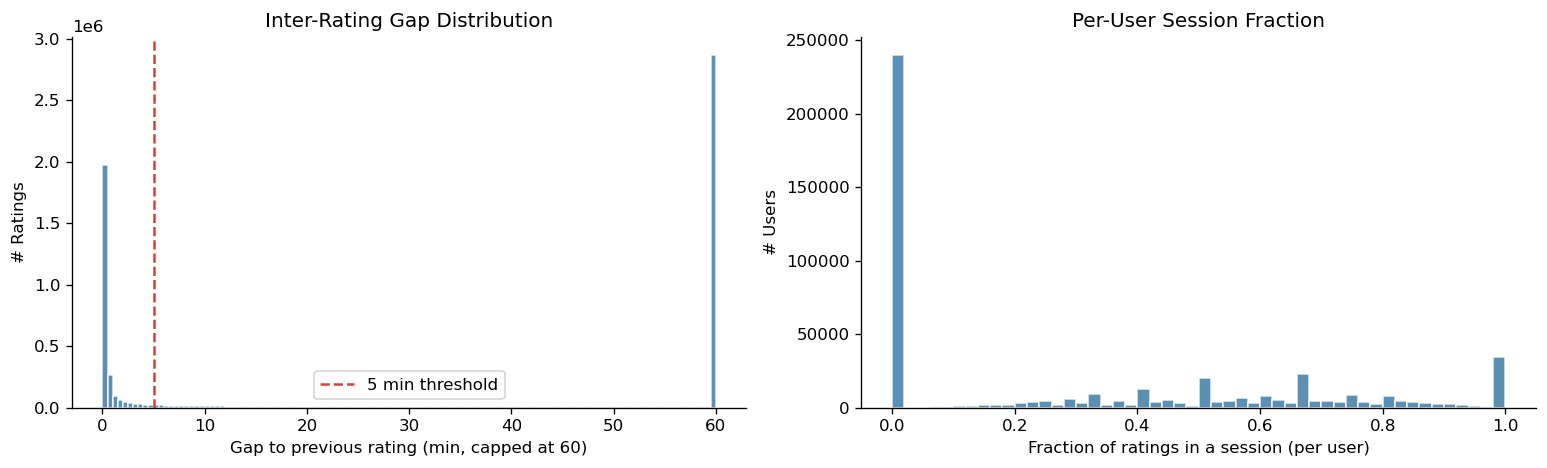

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(df['prev_gap_min'].dropna().clip(upper=60), bins=120, color=BLUE, alpha=0.8, edgecolor='white')
ax.axvline(SESSION_GAP_MINUTES, color=RED, linestyle='--', linewidth=1.5, label=f'{SESSION_GAP_MINUTES} min threshold')
ax.set_xlabel('Gap to previous rating (min, capped at 60)')
ax.set_ylabel('# Ratings')
ax.set_title('Inter-Rating Gap Distribution')
ax.legend()

ax = axes[1]
user_session = df.groupby('raterParticipantId').agg(total=('in_session','count'), sessions=('in_session','sum'))
user_session['session_frac'] = user_session['sessions'] / user_session['total']
ax.hist(user_session['session_frac'], bins=50, color=BLUE, alpha=0.8, edgecolor='white')
ax.set_xlabel('Fraction of ratings in a session (per user)')
ax.set_ylabel('# Users')
ax.set_title('Per-User Session Fraction')

plt.tight_layout()
plt.savefig('task3_sessions.png', bbox_inches='tight')
plt.show()

## Indicator 2: Post-Interest Rating

Flag ratings where the user rated >= 2 distinct notes on the same post (`ratedOnTweetId`).

In [6]:
POST_INTEREST_MIN = 2

user_post_counts = (
    df.groupby(['raterParticipantId', 'ratedOnTweetId'])['noteId']
    .nunique().reset_index(name='notes_on_post')
)

post_interest_pairs = user_post_counts[user_post_counts['notes_on_post'] >= POST_INTEREST_MIN][
    ['raterParticipantId', 'ratedOnTweetId']
].copy()
post_interest_pairs['post_interest'] = True

df = df.merge(post_interest_pairs, on=['raterParticipantId', 'ratedOnTweetId'], how='left')
df['post_interest'] = df['post_interest'].fillna(False)

pct_post = 100 * df['post_interest'].mean()
print(f'Post-interest ratings: {df["post_interest"].sum():,} / {len(df):,}  ({pct_post:.1f}%)')
print(user_post_counts['notes_on_post'].value_counts().sort_index().head(10))

Post-interest ratings: 3,309,659 / 6,499,635  (50.9%)
notes_on_post
1     3189976
2      754177
3      244798
4      100835
5       44331
6       22434
7       12297
8        6532
9        3733
10       2031
Name: count, dtype: int64


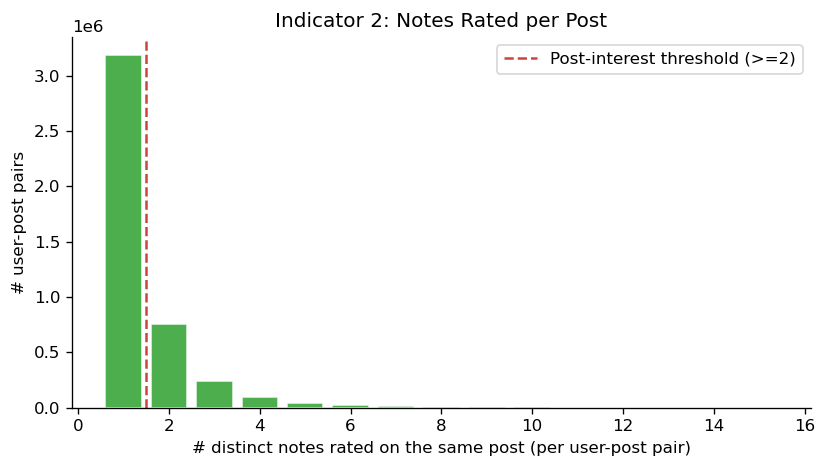

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
vc_plot = user_post_counts['notes_on_post'].value_counts().sort_index().head(15)
ax.bar(vc_plot.index, vc_plot.values, color=GREEN, edgecolor='white', alpha=0.85)
ax.axvline(POST_INTEREST_MIN - 0.5, color=RED, linestyle='--', linewidth=1.5,
           label=f'Post-interest threshold (>={POST_INTEREST_MIN})')
ax.set_xlabel('# distinct notes rated on the same post (per user-post pair)')
ax.set_ylabel('# user-post pairs')
ax.set_title('Indicator 2: Notes Rated per Post')
ax.legend()
plt.tight_layout()
plt.savefig('task3_post_interest.png', bbox_inches='tight')
plt.show()

## Indicator 3: Notification-Driven Rating

`fromNotification` is already a boolean in the data, so no computation needed.

In [8]:
df['from_notification'] = df['fromNotification']

pct_notif = 100 * df['from_notification'].mean()
print(f'Notification-driven ratings: {df["from_notification"].sum():,} / {len(df):,}  ({pct_notif:.1f}%)')

print(
    df.groupby('from_notification')['helpfulnessLevel']
    .value_counts(normalize=True).mul(100).round(1)
    .rename('pct').reset_index()
    .pivot(index='helpfulnessLevel', columns='from_notification', values='pct')
    .rename(columns={False: 'Not notif', True: 'From notif'})
)

Notification-driven ratings: 128,736 / 6,499,635  (2.0%)
from_notification  Not notif  From notif
helpfulnessLevel                        
HELPFUL                 61.8        80.5
NOT_HELPFUL             36.4        14.6
SOMEWHAT_HELPFUL         1.8         5.0


## Indicator 4: Rater Swarm

Flag ratings on notes where >= 50% of all ratings arrived in a single 1-hour window.

In [9]:
SWARM_MAJORITY_PCT = 0.50

df['rating_hour'] = df['ratingCreatedAt'].dt.floor('h')

note_total = df.groupby('noteId')['ratingCreatedAt'].count().rename('total_note_ratings')
note_max_hour = (
    df.groupby(['noteId', 'rating_hour'])['ratingCreatedAt'].count()
    .groupby(level='noteId').max().rename('max_hour_count')
)

swarm_df = pd.concat([note_total, note_max_hour], axis=1)
swarm_df['peak_hour_fraction'] = swarm_df['max_hour_count'] / swarm_df['total_note_ratings']
swarm_df['in_swarm_note'] = swarm_df['peak_hour_fraction'] >= SWARM_MAJORITY_PCT

df = df.merge(swarm_df[['in_swarm_note']], on='noteId', how='left')
df['in_swarm'] = df['in_swarm_note'].fillna(False)

swarm_notes = swarm_df['in_swarm_note'].sum()
print(f'Swarm notes: {swarm_notes:,} / {swarm_df.shape[0]:,}  ({100*swarm_notes/swarm_df.shape[0]:.1f}%)')
print(f'Ratings on swarm notes: {df["in_swarm"].sum():,} / {len(df):,}  ({100*df["in_swarm"].mean():.1f}%)')
print(swarm_df['peak_hour_fraction'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(3))

Swarm notes: 43,564 / 114,204  (38.1%)
Ratings on swarm notes: 179,975 / 6,499,635  (2.8%)
count    114204.000
mean          0.462
std           0.347
min           0.013
25%           0.176
50%           0.319
75%           1.000
90%           1.000
95%           1.000
99%           1.000
max           1.000
Name: peak_hour_fraction, dtype: float64


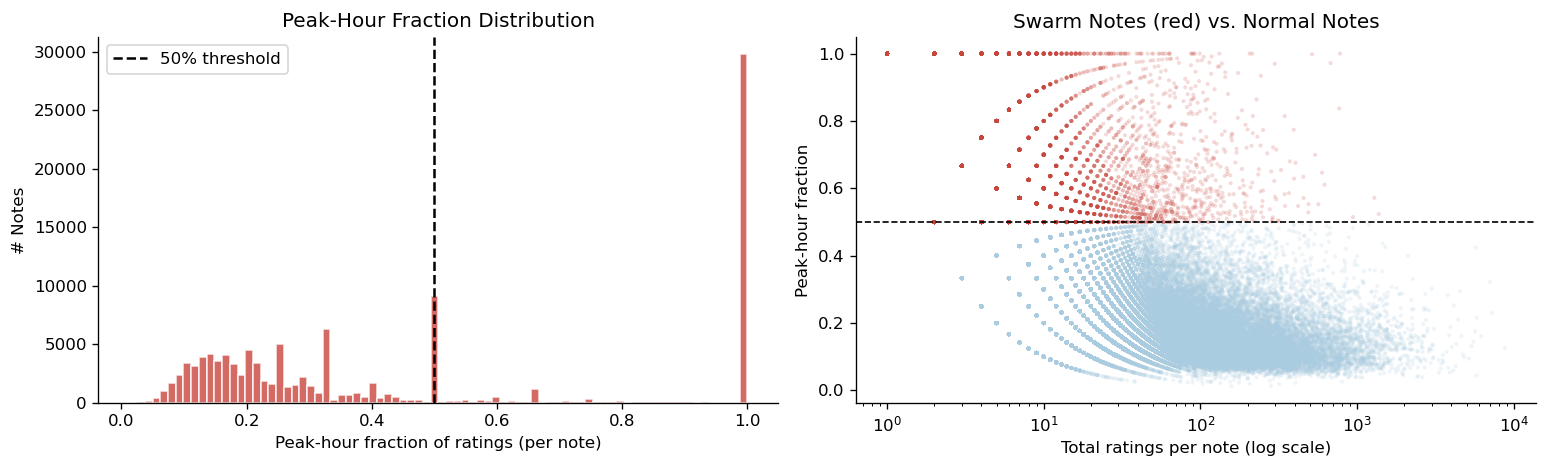

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(swarm_df['peak_hour_fraction'], bins=80, color=RED, alpha=0.8, edgecolor='white')
ax.axvline(SWARM_MAJORITY_PCT, color='black', linestyle='--', linewidth=1.5, label=f'{int(SWARM_MAJORITY_PCT*100)}% threshold')
ax.set_xlabel('Peak-hour fraction of ratings (per note)')
ax.set_ylabel('# Notes')
ax.set_title('Peak-Hour Fraction Distribution')
ax.legend()

ax = axes[1]
colors_swarm = swarm_df['in_swarm_note'].map({True: RED, False: '#aacce0'})
ax.scatter(swarm_df['total_note_ratings'], swarm_df['peak_hour_fraction'],
           c=colors_swarm, alpha=0.2, s=6, linewidths=0)
ax.axhline(SWARM_MAJORITY_PCT, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Total ratings per note (log scale)')
ax.set_ylabel('Peak-hour fraction')
ax.set_title('Swarm Notes (red) vs. Normal Notes')

plt.tight_layout()
plt.savefig('task3_swarms.png', bbox_inches='tight')
plt.show()

## Summary

In [11]:
indicators = {
    'in_session':        ('Session (<=5 min gap)',   BLUE),
    'post_interest':     ('Post-Interest (>=2/post)', GREEN),
    'from_notification': ('Notification',             GRAY),
    'in_swarm':          ('Swarm (>=50% in 1h)',      RED),
}

print(f"{'Indicator':<30} {'Count':>10} {'%':>8}")
print('-' * 52)
for col, (label, _) in indicators.items():
    n = int(df[col].sum())
    pct = 100 * df[col].mean()
    print(f"{label:<30} {n:>10,} {pct:>7.1f}%")
print(f"{'Total':<30} {len(df):>10,}")

Indicator                           Count        %
----------------------------------------------------
Session (<=5 min gap)           3,837,599    59.0%
Post-Interest (>=2/post)        3,309,659    50.9%
Notification                      128,736     2.0%
Swarm (>=50% in 1h)               179,975     2.8%
Total                           6,499,635


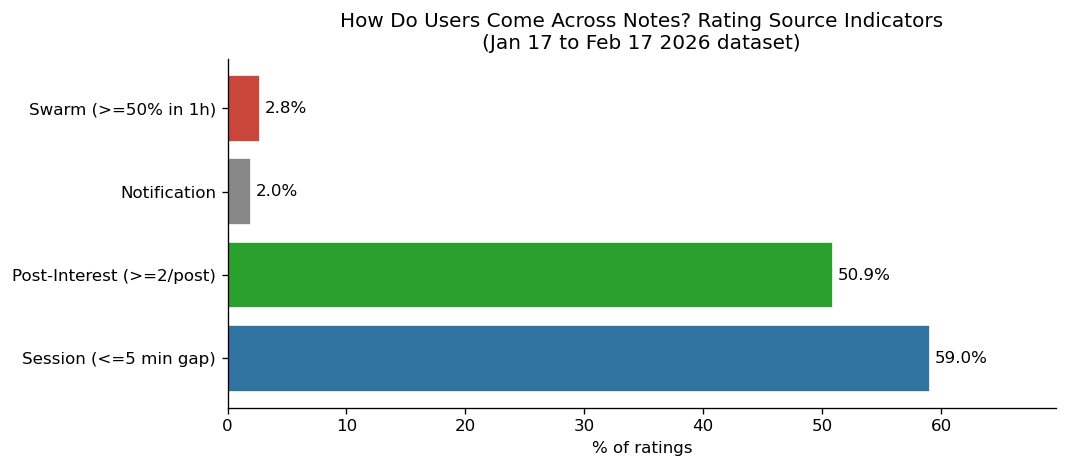

In [12]:
labels = [label for label, _ in indicators.values()]
colors = [color for _, color in indicators.values()]
pcts   = [100 * df[col].mean() for col in indicators]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, pcts, color=colors, edgecolor='white')
for bar, pct in zip(bars, pcts):
    ax.text(pct + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% of ratings')
ax.set_xlim(0, max(pcts) * 1.18)
ax.set_title('How Do Users Come Across Notes? Rating Source Indicators\n'
             '(Jan 17 to Feb 17 2026 dataset)', fontsize=12)
plt.tight_layout()
plt.savefig('task3_indicator_summary.png', bbox_inches='tight')
plt.show()

In [13]:
cols = list(indicators.keys())
comat = pd.DataFrame(index=cols, columns=cols, dtype=float)
for c1 in cols:
    for c2 in cols:
        comat.loc[c1, c2] = round(100 * (df[c1] & df[c2]).mean(), 2)
comat.index = comat.columns = [indicators[c][0][:18] for c in cols]
print('Co-occurrence (% of all ratings):')
print(comat.to_string())

Co-occurrence (% of all ratings):
                    Session (<=5 min g  Post-Interest (>=2  Notification  Swarm (>=50% in 1h
Session (<=5 min g               59.04               49.85          0.56                1.51
Post-Interest (>=2               49.85               50.92          0.11                1.19
Notification                      0.56                0.11          1.98                0.04
Swarm (>=50% in 1h                1.51                1.19          0.04                2.77


In [14]:
output_cols = [
    'noteId', 'ratedOnTweetId', 'raterParticipantId', 'noteAuthorParticipantId',
    'postCreatedAt', 'noteCreatedAt', 'ratingCreatedAt', 'helpfulnessLevel', 'fromNotification',
    'in_session', 'post_interest', 'from_notification', 'in_swarm',
]

df[output_cols].to_parquet('../../data/ratings-enriched.parquet', index=False)
print(f'Saved: {df[output_cols].shape}')

Saved: (6499635, 13)
